In [1]:
from langchain_community.document_loaders import PyPDFLoader

In [2]:
upload_file = ""


loader = PyPDFLoader(upload_file)

docs = loader.load()



ValueError: File path  is not a valid file or url

In [1]:
import os 
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq


llm = ChatGroq(model="openai/gpt-oss-120b")


llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B113C36BA0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B113C378C0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [3]:
from typing import TypedDict,Annotated,List
from langgraph.graph.message import add_messages
from pydantic import BaseModel


c:\Users\AYMAN KHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
class State(BaseModel):
    messages: str

In [5]:
def llm_node(query:dict)-> dict:
    response = llm.invoke(query)
    return  response
   

In [6]:
from langgraph.graph import  StateGraph,START,END

In [7]:
builder = StateGraph(dict)


In [8]:
from langchain.tools import tool
from dotenv import load_dotenv
load_dotenv()

import os 

os.environ["TAVILY_SEARCH_API"]  = os.getenv("TAVILY_SEARCH_API")

In [9]:
from langchain_community.tools.tavily_search import TavilySearchResults 
tavily_api_key = "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"


web_search = TavilySearchResults(max_results=5, tavily_api_key="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")

C:\Users\AYMAN KHAN\AppData\Local\Temp\ipykernel_11236\1579069906.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search = TavilySearchResults(max_results=5, tavily_api_key="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")


In [10]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [16]:
from pydantic import BaseModel


class agentstate(BaseModel):
    user_reponse : str
    content : list[str]
    

In [21]:
from langgraph.prebuilt import ToolNode


tools = [web_search]

tool_node = ToolNode(tools)


llm_with_tools = llm.bind_tools(tools)


def tool_calling_llm(state :agentstate):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


In [22]:
builder = StateGraph(agentstate)

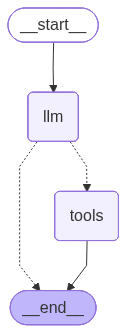

In [23]:
from langgraph.prebuilt import tools_condition

builder.add_node("llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm")
builder.add_conditional_edges("llm",tools_condition)
builder.add_edge("tools",END)


graph = builder.compile()


graph

In [25]:
#user_input = input("Enter your question:  ")

query = {
    "user_input" : "what is the current ai news?",
    "content" : "content should be in this section"
  }

response = graph.invoke(query)

print(response)

ValidationError: 2 validation errors for agentstate
user_reponse
  Field required [type=missing, input_value={'content': 'content should be in this section'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.11/v/missing
content
  Input should be a valid list [type=list_type, input_value='content should be in this section', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/list_type

In [2]:
from langchain_community.document_loaders import PyMuPDFLoader

from langchain_community.vectorstores import Chroma 
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
 

from langchain.messages import AIMessage,HumanMessage


from langchain_text_splitters import RecursiveCharacterTextSplitter


from langgraph.graph import StateGraph
from langchain.agents import create_agent
 

In [ ]:
agent = create_agent(
    model=
    tools=
   response_format=
)

In [1]:
1+1

2